In [1]:
import torch
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


Tesla T4


In [2]:
!pip install -q torch torchvision torchaudio \
transformers==4.30.0 datasets==2.12.0 accelerate==0.20.3 \
scikit-learn pandas numpy tqdm fsspec==2023.6.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 13.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.6/474.6 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 7.9 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is li

In [3]:
!pip install drain3

  Preparing metadata (setup.py) ... done
  Created wheel for drain3: filename=drain3-0.9.11-py3-none-any.whl size=23998 sha256=caa1b68122f43c85e37994492090a4c1d04c056c09435eff2dcf80c296a86f28
  Stored in directory: /root/.cache/pip/wheels/3f/d1/46/58e1747b3d77c4990f838e1c1f610f5aab1a21889cc9bff5c2
Successfully built drain3
  Attempting uninstall: jsonpickle
    Found existing installation: jsonpickle 4.1.1
    Uninstalling jsonpickle-4.1.1:
      Successfully uninstalled jsonpickle-4.1.1
  Attempting uninstall: cachetools
    Found existing installation: cachetools 5.5.2
    Uninstalling cachetools-5.5.2:
      Successfully uninstalled cachetools-5.5.2


In [4]:
import torch, transformers, tokenizers, datasets
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())
print("transformers:", transformers.__version__)
print("tokenizers:", tokenizers.__version__)
print("datasets:", datasets.__version__)


torch: 2.8.0+cu126 | cuda: True
transformers: 4.57.1
tokenizers: 0.22.1
datasets: 4.0.0


In [5]:
# 1) Upload files
#!pip install -q --upgrade transformers torch accelerate
MODEL_ID="distilbert-base-uncased-finetuned-sst-2-english"  # binary classifier
!python classify_with_distilbert.py \
  --mapping_csv logs_to_templates.csv \
  --distilbert_model "$MODEL_ID" \
  --line_by_line --batch_size 64


tokenizer_config.json: 100% 48.0/48.0 [00:00<00:00, 266kB/s]
config.json: 100% 629/629 [00:00<00:00, 3.76MB/s]
vocab.txt: 100% 232k/232k [00:00<00:00, 11.5MB/s]
2025-11-09 20:47:00.697113: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762721220.772978    2020 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762721220.785134    2020 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762721220.822810    2020 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762721220.822853    2020 computation_placer.cc:177] computation placer already registere

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
import json

# labels file (has: raw,label_band or line_idx,label_band)
labels = pd.read_csv("distilbert_lines.csv")
maps   = pd.read_csv("logs_to_templates.csv")  # now has template_text

# Merge labels to templates. Prefer exact 'raw' join; if not stable, use line_idx.
if "raw" in labels.columns:
    df = labels.merge(maps[["raw","template_text"]].drop_duplicates(), on="raw", how="inner")
else:
    df = labels.merge(maps[["line_idx","template_text"]].drop_duplicates(), on="line_idx", how="inner")

df = df[df["label_band"].isin(["relevant","irrelevant"])].copy()
df = df[["template_text","label_band"]].dropna().drop_duplicates()
df = df.rename(columns={"template_text":"text"})

label_map = {"irrelevant":0, "relevant":1}
df["label_id"] = df["label_band"].map(label_map)

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label_id"])
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
with open("label_map.json","w") as f: json.dump(label_map, f, indent=2)

print("Saved train.csv, val.csv, label_map.json")


Saved train.csv, val.csv, label_map.json


In [ ]:
import json, random, numpy as np, pandas as pd, torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, set_seed
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

SEED = 13
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); set_seed(SEED)

# 1) Load
train_df = pd.read_csv("train.csv")
val_df   = pd.read_csv("val.csv")

# Pick text column
CANDIDATES = ["seq_text", "text", "line", "raw", "message", "content"]
TEXT_COL = next((c for c in CANDIDATES if c in train_df.columns), None)
if TEXT_COL is None:
    raise ValueError(f"No text column found. Expected one of {CANDIDATES}, got {list(train_df.columns)}")

if "label_id" not in train_df.columns or "label_id" not in val_df.columns:
    raise ValueError("Expected 'label_id' column in both train.csv and val.csv")

# Keep needed cols and correct dtype
train_df = train_df[[TEXT_COL, "label_id"]].copy()
val_df   = val_df[[TEXT_COL, "label_id"]].copy()
train_df["label_id"] = train_df["label_id"].astype("int64")
val_df["label_id"]   = val_df["label_id"].astype("int64")

# 2) HF datasets
ds = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(val_df, preserve_index=False),
})

# 3) Tokenizer & model
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

label2id = {"irrelevant": 0, "relevant": 1}
id2label = {v: k for k, v in label2id.items()}
num_labels = int(pd.concat([train_df["label_id"], val_df["label_id"]]).nunique())

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label if num_labels == 2 else {i: str(i) for i in range(num_labels)},
    label2id=label2id if num_labels == 2 else {str(i): i for i in range(num_labels)},
)

# 4) Tokenize
max_length = 256
def tokenize(batch):
    return tokenizer(batch[TEXT_COL], padding=True, truncation=True, max_length=max_length)

ds_enc = ds.map(tokenize, batched=True)
ds_enc = ds_enc.rename_column("label_id", "labels")
ds_enc.set_format(type="torch", columns=["input_ids","attention_mask","labels"])

# 5) Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "precision_weighted": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall_weighted": recall_score(labels, preds, average="weighted", zero_division=0),
    }

# 6) Training args
use_fp16 = torch.cuda.is_available()
args = TrainingArguments(
    output_dir="outputs/distilbert-logcls",
    eval_strategy="epoch",     # <-- fixed name
    save_strategy="epoch",
    save_total_limit=2,
    logging_steps=50,
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=use_fp16,
    report_to="none",
    seed=SEED,
)

# 7) Train
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_enc["train"],
    eval_dataset=ds_enc["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)
trainer.train()

# 8) Save model + tokenizer + label map
save_dir = "outputs/distilbert-logcls/best"
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)  # <-- ensure tokenizer is saved too

with open(f"{save_dir}/label_map.json","w") as f:
    if num_labels == 2:
        json.dump({"id2label": id2label, "label2id": label2id}, f, indent=2)
    else:
        json.dump({"id2label": {i: str(i) for i in range(num_labels)},
                   "label2id": {str(i): i for i in range(num_labels)}}, f, indent=2)

print(f"Saved checkpoint to {save_dir}. Using TEXT_COL='{TEXT_COL}', num_labels={num_labels}.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Map:   0%|          | 0/657 [00:00<?, ? examples/s]

Map:   0%|          | 0/165 [00:00<?, ? examples/s]

/tmp/ipython-input-4118579168.py:95: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,Precision Weighted,Recall Weighted
1,No log,0.422641,0.866667,0.865201,0.862417,0.870401,0.866667
2,0.576600,0.333191,0.854545,0.854044,0.851663,0.854567,0.854545
3,0.371800,0.332134,0.854545,0.854044,0.851663,0.854567,0.854545


Saved checkpoint to outputs/distilbert-logcls/best. Using TEXT_COL='text', num_labels=2.


In [ ]:
from transformers import AutoConfig
cfg = AutoConfig.from_pretrained("outputs/distilbert-logcls/best")
cfg.id2label = {0:"irrelevant",1:"relevant"}
cfg.label2id = {"irrelevant":0,"relevant":1}
cfg.save_pretrained("outputs/distilbert-logcls/best")


In [ ]:
 !ls -la "outputs/distilbert-logcls/best"

total 262512
drwxr-xr-x 2 root root      4096 Oct 31 14:52 .
drwxr-xr-x 5 root root      4096 Oct 31 14:52 ..
-rw-r--r-- 1 root root       687 Oct 31 14:53 config.json
-rw-r--r-- 1 root root       126 Oct 31 14:52 label_map.json
-rw-r--r-- 1 root root 267832560 Oct 31 14:52 model.safetensors
-rw-r--r-- 1 root root       125 Oct 31 14:52 special_tokens_map.json
-rw-r--r-- 1 root root      1227 Oct 31 14:52 tokenizer_config.json
-rw-r--r-- 1 root root    711649 Oct 31 14:52 tokenizer.json
-rw-r--r-- 1 root root      5841 Oct 31 14:52 training_args.bin
-rw-r--r-- 1 root root    231508 Oct 31 14:52 vocab.txt


In [ ]:
## Demo Inference start - Cell1

# Cell 1: Load the attached CSV and pick 3 example templates (rows 0,3,7)
import pandas as pd

CSV_PATH = "/content/examples_inference.csv"

df = pd.read_csv(CSV_PATH)
print("CSV columns:", list(df.columns))

# Deterministic subset for demo
SAMPLE_IDX = [0, 3, 7]
sample_df = df.loc[SAMPLE_IDX, ["raw_log", "template_text"]].reset_index(drop=True)

print("\n=== 3 Example Logs with their Templates (from CSV) ===\n")
for i, row in sample_df.iterrows():
    print(f"[{i+1}] RAW : {row['raw_log']}")
    print(f"    TEMPLATE → {row['template_text']}\n")

EXAMPLE_TEMPLATES = sample_df["template_text"].tolist()



CSV columns: ['raw_log', 'template_text', 'p_irrelevant', 'p_relevant', 'pred_label']

=== 3 Example Logs with their Templates (from CSV) ===

[1] RAW : ts=2025-10-18T01:24:13.299981Z level=INFO ns=dev svc=order-svc pod=order-svc-006 region=eu-central-1 host=node-045 rid=- uid=- tid=- msg=Received_request_PATCH_/metrics_status=429_latency=1526ms_bytes=4588533
    TEMPLATE → ts=2025-10-18T01:<PORT>:<PORT>.299981Z level=INFO ns=dev svc=order-svc pod=order-svc-006 region=eu-central-1 host=node-045 rid=- uid=- tid=- msg=Received_request_PATCH_/metrics_status=429_latency=1526ms_bytes=4588533

[2] RAW : 2025-10-18T22:40:24.479640Z WARN prod.kafka-consumer/kafka-consumer-008 [us-east-1 node-009] rid=- uid=user-9690 tid=- - GC cycle completed pause=189ms freed=762MB
    TEMPLATE → WARN prod.kafka-consumer/kafka-consumer-008 [us-east-1 node-009] rid=- uid=user-9690 tid=- - GC cycle completed pause=189ms freed=762MB

[3] RAW : 2025-10-18T14:52:49.956777Z WARN prod.loki-ingestor/loki-ingestor-003

In [ ]:
## Demo Inference start - Cell2
# Cell 2: Inference using base DistilBERT (sentiment)
# POSITIVE → relevant, NEGATIVE → irrelevant

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TextClassificationPipeline
import torch, pandas as pd

BASE_MODEL = "distilbert-base-uncased-finetuned-sst-2-english"
device = 0 if torch.cuda.is_available() else -1

pipe_base = TextClassificationPipeline(
    model=AutoModelForSequenceClassification.from_pretrained(BASE_MODEL),
    tokenizer=AutoTokenizer.from_pretrained(BASE_MODEL),
    device=device,
    return_all_scores=True,
    truncation=True,
)

def infer_base(texts):
    rows = []
    for txt, out in zip(texts, pipe_base(texts)):
        scores = {d["label"]: d["score"] for d in out}
        p_irrel, p_rel = scores["NEGATIVE"], scores["POSITIVE"]
        label = "relevant" if p_rel >= p_irrel else "irrelevant"
        rows.append(dict(template_text=txt,
                         base_label=label,
                         base_p_irrelevant=round(p_irrel,4),
                         base_p_relevant=round(p_rel,4)))
    return pd.DataFrame(rows)

base_df = infer_base(EXAMPLE_TEMPLATES)
print("\n=== Base Model Output (on templates) ===")
display(base_df)


Device set to use cuda:0



=== Base Model Output (on templates) ===


/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


,template_text,base_label,base_p_irrelevant,base_p_relevant
0,ts=2025-10-18T01:<PORT>:<PORT>.299981Z level=I...,irrelevant,0.9971,0.0029
1,WARN prod.kafka-consumer/kafka-consumer-008 [u...,irrelevant,0.9986,0.0014
2,WARN prod.loki-ingestor/loki-ingestor-003 [eu-...,irrelevant,0.9974,0.0026


In [ ]:
## Demo Inference start - Cell3
# Cell 3: Fine-tuned DistilBERT inference on same templates
# Update FINETUNED_DIR to your actual fine-tuned model path

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch, torch.nn.functional as F, os, pandas as pd

FINETUNED_DIR = "outputs/distilbert-logcls/best"  # <-- change path if needed
LABELS = ["irrelevant", "relevant"]

if not os.path.isdir(FINETUNED_DIR):
    raise FileNotFoundError(f"Fine-tuned model not found at {FINETUNED_DIR}")

tok = AutoTokenizer.from_pretrained(FINETUNED_DIR)
model = AutoModelForSequenceClassification.from_pretrained(FINETUNED_DIR).eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def infer_ft(texts):
    enc = tok(texts, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.no_grad():
        probs = F.softmax(model(**enc).logits, dim=-1).cpu().numpy()
    rows = []
    for txt, p in zip(texts, probs):
        p_irrel, p_rel = map(float, p)
        label = "relevant" if p_rel >= p_irrel else "irrelevant"
        rows.append(dict(template_text=txt,
                         ft_label=label,
                         ft_p_irrelevant=round(p_irrel,4),
                         ft_p_relevant=round(p_rel,4)))
    return pd.DataFrame(rows)

ft_df = infer_ft(EXAMPLE_TEMPLATES)
print("\n=== Fine-tuned Model Output (on templates) ===")
display(ft_df)



=== Fine-tuned Model Output (on templates) ===


,template_text,ft_label,ft_p_irrelevant,ft_p_relevant
0,ts=2025-10-18T01:<PORT>:<PORT>.299981Z level=I...,relevant,0.2571,0.7429
1,WARN prod.kafka-consumer/kafka-consumer-008 [u...,irrelevant,0.6076,0.3924
2,WARN prod.loki-ingestor/loki-ingestor-003 [eu-...,relevant,0.2649,0.7351


In [ ]:
# Cell 4: Merge for side-by-side comparison (template_text + results)
comparison = base_df.merge(ft_df, on="template_text", how="inner")
final_df = sample_df.merge(comparison, on="template_text", how="inner")

print("\n=== Base vs Fine-tuned Comparison ===")
display(final_df[[
    "raw_log",
    "template_text",
    "base_label","base_p_irrelevant","base_p_relevant",
    "ft_label","ft_p_irrelevant","ft_p_relevant"
]])



=== Base vs Fine-tuned Comparison ===


,raw_log,template_text,base_label,base_p_irrelevant,base_p_relevant,ft_label,ft_p_irrelevant,ft_p_relevant
0,ts=2025-10-18T01:24:13.299981Z level=INFO ns=d...,ts=2025-10-18T01:<PORT>:<PORT>.299981Z level=I...,irrelevant,0.9971,0.0029,relevant,0.2571,0.7429
1,2025-10-18T22:40:24.479640Z WARN prod.kafka-co...,WARN prod.kafka-consumer/kafka-consumer-008 [u...,irrelevant,0.9986,0.0014,irrelevant,0.6076,0.3924
2,2025-10-18T14:52:49.956777Z WARN prod.loki-ing...,WARN prod.loki-ingestor/loki-ingestor-003 [eu-...,irrelevant,0.9974,0.0026,relevant,0.2649,0.7351


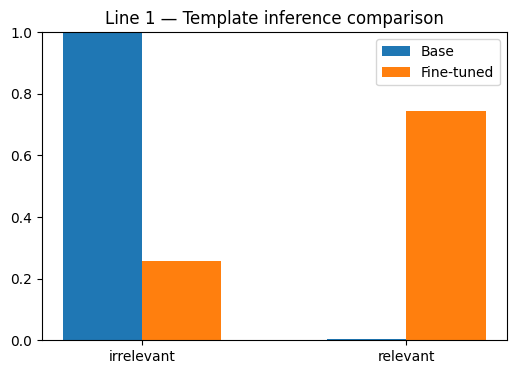

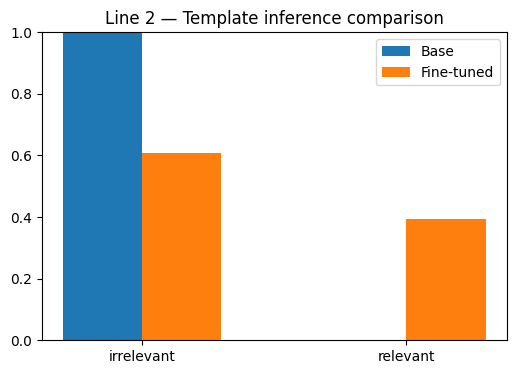

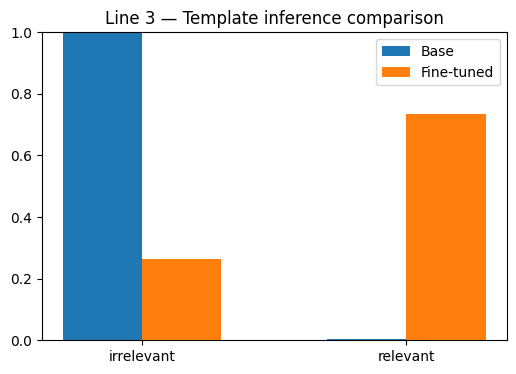

In [ ]:
# # Cell 5: Optional visualization of probabilities
import matplotlib.pyplot as plt
import numpy as np

for i, row in final_df.iterrows():
    x = np.arange(2)
    base_vals = [row["base_p_irrelevant"], row["base_p_relevant"]]
    ft_vals   = [row["ft_p_irrelevant"], row["ft_p_relevant"]]
    plt.figure(figsize=(6,4))
    plt.bar(x-0.15, base_vals, width=0.3, label="Base")
    plt.bar(x+0.15, ft_vals,  width=0.3, label="Fine-tuned")
    plt.xticks(x, ["irrelevant", "relevant"])
    plt.ylim(0,1)
    plt.title(f"Line {i+1} — Template inference comparison")
    plt.legend()
    plt.show()


In [ ]:
# Cell A: Mount Google Drive and create a timestamped export directory
from google.colab import drive
from datetime import datetime
from pathlib import Path

drive.mount('/content/drive', force_remount=True)

# Change this root if you prefer another Drive folder
DRIVE_ROOT = Path("/content/drive/MyDrive")
EXP_NAME = f"log-demo-{datetime.now().strftime('%Y%m%d-%H%M%S')}"
EXP_DIR = DRIVE_ROOT / EXP_NAME
PLOTS_DIR = EXP_DIR / "plots"
MODEL_DIR = EXP_DIR / "finetuned-model"

for p in [EXP_DIR, PLOTS_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"[OK] Export folder: {EXP_DIR}")


Mounted at /content/drive
[OK] Export folder: /content/drive/MyDrive/log-demo-20251031-150815


In [ ]:
# Cell B: Copy the input CSV into Drive so the demo is self-contained
import shutil, os

CSV_PATH = "/content/examples_inference.csv"  # same as your previous cells
assert os.path.exists(CSV_PATH), f"Input CSV not found at {CSV_PATH}"

dst_csv = EXP_DIR / "examples_inference.csv"
shutil.copy2(CSV_PATH, dst_csv)
print(f"[OK] Copied demo CSV to: {dst_csv}")


[OK] Copied demo CSV to: /content/drive/MyDrive/log-demo-20251031-150815/examples_inference.csv


In [ ]:
# Cell C: Save results dataframes to Drive
import pandas as pd

artifacts = {}

if 'base_df' in globals():
    artifacts['base_df.csv'] = base_df
if 'ft_df' in globals():
    artifacts['ft_df.csv'] = ft_df
if 'comparison' in globals():
    artifacts['comparison.csv'] = comparison
if 'final_df' in globals():
    artifacts['final_df.csv'] = final_df  # has raw_log + template_text + both outputs

if not artifacts:
    print("[WARN] No result DataFrames found. Run inference cells first.")
else:
    for name, df in artifacts.items():
        out_path = EXP_DIR / name
        df.to_csv(out_path, index=False)
        print(f"[OK] Saved {name} -> {out_path}")


[OK] Saved base_df.csv -> /content/drive/MyDrive/log-demo-20251031-150815/base_df.csv
[OK] Saved ft_df.csv -> /content/drive/MyDrive/log-demo-20251031-150815/ft_df.csv
[OK] Saved comparison.csv -> /content/drive/MyDrive/log-demo-20251031-150815/comparison.csv
[OK] Saved final_df.csv -> /content/drive/MyDrive/log-demo-20251031-150815/final_df.csv


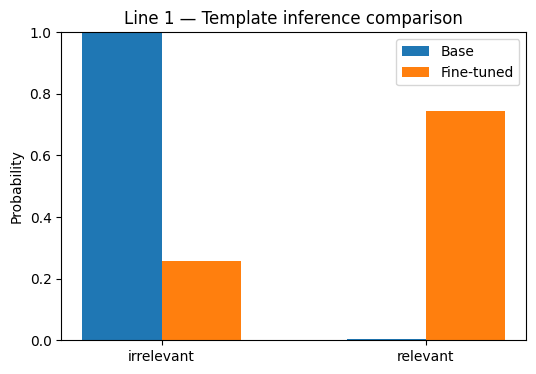

[OK] Saved plot: /content/drive/MyDrive/log-demo-20251031-150815/plots/line_1.png


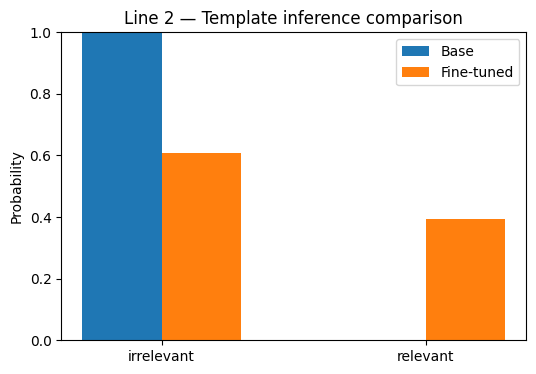

[OK] Saved plot: /content/drive/MyDrive/log-demo-20251031-150815/plots/line_2.png


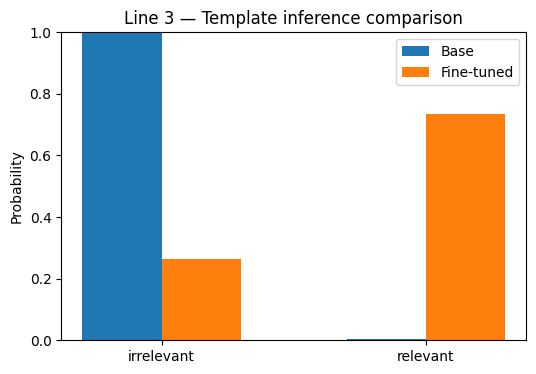

[OK] Saved plot: /content/drive/MyDrive/log-demo-20251031-150815/plots/line_3.png


In [ ]:
# Cell D: Save plots to Drive (and display)
import matplotlib.pyplot as plt
import numpy as np

if 'final_df' not in globals():
    raise RuntimeError("final_df not found. Run the comparison cell first.")

for i, row in final_df.iterrows():
    x = np.arange(2)
    base_vals = [row["base_p_irrelevant"], row["base_p_relevant"]]
    ft_vals   = [row["ft_p_irrelevant"],   row["ft_p_relevant"]]

    plt.figure(figsize=(6,4))
    plt.bar(x-0.15, base_vals, width=0.3, label="Base")
    plt.bar(x+0.15, ft_vals,  width=0.3, label="Fine-tuned")
    plt.xticks(x, ["irrelevant", "relevant"])
    plt.ylim(0,1)
    plt.title(f"Line {i+1} — Template inference comparison")
    plt.legend()
    plt.ylabel("Probability")

    out_png = PLOTS_DIR / f"line_{i+1}.png"
    plt.savefig(out_png, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"[OK] Saved plot: {out_png}")


In [ ]:
# Cell E: Save the fine-tuned model into Drive
import os, shutil
from pathlib import Path

# If you used this earlier:
# FINETUNED_DIR = "./models/distilbert-finetuned-logs"

saved = False

# Path-based copy (existing model folder)
if 'FINETUNED_DIR' in globals() and os.path.isdir(FINETUNED_DIR):
    src = Path(FINETUNED_DIR)
    dst = MODEL_DIR
    # Copy folder contents (config.json, tokenizer files, pytorch_model.bin, etc.)
    for item in src.iterdir():
        src_item = item
        dst_item = dst / item.name
        if src_item.is_dir():
            shutil.copytree(src_item, dst_item, dirs_exist_ok=True)
        else:
            shutil.copy2(src_item, dst_item)
    print(f"[OK] Copied fine-tuned model folder to: {dst}")
    saved = True

# In-memory save_pretrained (if model/tok variables exist)
try:
    if ('model' in globals()) and ('tok' in globals()):
        model.save_pretrained(MODEL_DIR.as_posix())
        tok.save_pretrained(MODEL_DIR.as_posix())
        print(f"[OK] Saved in-memory model/tokenizer to: {MODEL_DIR}")
        saved = True
except Exception as e:
    print(f"[WARN] save_pretrained failed: {e}")

if not saved:
    raise RuntimeError(
        "Could not save the fine-tuned model. "
        "Ensure either FINETUNED_DIR exists or 'model' and 'tok' are loaded."
    )


[OK] Copied fine-tuned model folder to: /content/drive/MyDrive/log-demo-20251031-150815/finetuned-model
[OK] Saved in-memory model/tokenizer to: /content/drive/MyDrive/log-demo-20251031-150815/finetuned-model


In [ ]:
# 🔧 Inference on 3 hardcoded Drain3-style TEMPLATES (not raw logs)

import os, torch, torch.nn.functional as F
import pandas as pd
from IPython.display import display

# --- Hardcoded templates (examples) ---
TEMPLATES = [
    "WARN prod.kafka-consumer/<POD> [<REGION>] partition=<NUM> lag=<NUM> exceeded threshold=<NUM>",
    "ERROR payment-svc/<POD> [<REGION>] Stripe request failed code=<NUM> after retries=<NUM>",
    "INFO cache-svc/<POD> [<REGION>] refresh completed items=<NUM> duration_ms=<NUM>"
]

# --- Reuse already loaded fine-tuned model if present; otherwise load from folder ---
FINETUNED_DIR = "outputs/distilbert-logcls/best"  # <-- change if needed

if 'tok' in globals() and 'model' in globals():
    tokenizer = tok
    clf = model
    device = next(clf.parameters()).device
else:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    if not os.path.isdir(FINETUNED_DIR):
        raise FileNotFoundError(f"Fine-tuned model not found at {FINETUNED_DIR}")
    tokenizer = AutoTokenizer.from_pretrained(FINETUNED_DIR)
    clf = AutoModelForSequenceClassification.from_pretrained(FINETUNED_DIR).eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    clf.to(device)

def infer_on_templates(templates, max_length=512):
    enc = tokenizer(templates, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
    with torch.no_grad():
        probs = F.softmax(clf(**enc).logits, dim=-1).cpu().numpy()
    rows = []
    for tmpl, p in zip(templates, probs):
        p_irrel, p_rel = map(float, p)  # assumes label order: [irrelevant, relevant]
        label = "relevant" if p_rel >= p_irrel else "irrelevant"
        rows.append({
            "template_text": tmpl,
            "ft_label": label,
            "ft_p_irrelevant": round(p_irrel, 4),
            "ft_p_relevant": round(p_rel, 4),
        })
    return pd.DataFrame(rows)

out_df = infer_on_templates(TEMPLATES)
print("=== Fine-tuned model predictions on hardcoded templates ===")
display(out_df)


=== Fine-tuned model predictions on hardcoded templates ===


,template_text,ft_label,ft_p_irrelevant,ft_p_relevant
0,WARN prod.kafka-consumer/<POD> [<REGION>] part...,irrelevant,0.5076,0.4924
1,ERROR payment-svc/<POD> [<REGION>] Stripe requ...,irrelevant,0.8542,0.1458
2,INFO cache-svc/<POD> [<REGION>] refresh comple...,relevant,0.3069,0.6931


In [ ]:
# Inspect id2label / label2id so we don't guess the order.
print("id2label:", getattr(model.config, "id2label", None))
print("label2id:", getattr(model.config, "label2id", None))


id2label: {0: 'irrelevant', 1: 'relevant'}
label2id: {'irrelevant': 0, 'relevant': 1}


In [ ]:
# Re-run inference with explicit class indices from model.config
import torch, torch.nn.functional as F
import pandas as pd

# Your three templates (edit as needed)
TEMPLATES = [
    "WARN prod.kafka-consumer/<POD> [<REGION>] partition=<NUM> lag=<NUM> exceeded threshold=<NUM>",
    "ERROR payment-svc/<POD> [<REGION>] Stripe request failed code=<NUM> after retries=<NUM>",
    "INFO cache-svc/<POD> [<REGION>] refresh completed items=<NUM> duration_ms=<NUM>"
]

# Resolve class indices from the loaded model
idx_irrelevant = model.config.label2id["irrelevant"]
idx_relevant   = model.config.label2id["relevant"]

def infer_templates(templates):
    enc = tok(templates, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.no_grad():
        probs = F.softmax(model(**enc).logits, dim=-1).cpu().numpy()
    rows = []
    for tmpl, p in zip(templates, probs):
        p_irrel = float(p[idx_irrelevant])
        p_rel   = float(p[idx_relevant])
        label   = "relevant" if p_rel >= p_irrel else "irrelevant"
        rows.append({
            "template_text": tmpl,
            "ft_p_irrelevant": round(p_irrel, 4),
            "ft_p_relevant": round(p_rel, 4),
            "ft_label": label
        })
    return pd.DataFrame(rows)

orig_df = infer_templates(TEMPLATES)
print("=== Original templates (no normalization) ===")
display(orig_df)


=== Original templates (no normalization) ===


,template_text,ft_p_irrelevant,ft_p_relevant,ft_label
0,WARN prod.kafka-consumer/<POD> [<REGION>] part...,0.5076,0.4924,irrelevant
1,ERROR payment-svc/<POD> [<REGION>] Stripe requ...,0.8542,0.1458,irrelevant
2,INFO cache-svc/<POD> [<REGION>] refresh comple...,0.3069,0.6931,relevant


In [ ]:
# Normalize variable tokens to the style you trained with (adjust rules to match your Drain3 training)
import re
import pandas as pd

def normalize_placeholders(s: str) -> str:
    t = s

    # Replace your custom placeholders with training-style wildcard (e.g., "<*>")
    t = (t.replace("<NUM>", "<*>")
           .replace("<POD>", "<*>")
           .replace("<REGION>", "<*>"))

    # Also scrub dynamic literals that your training likely generalized:
    # numbers, hex IDs, UUIDs, IPs, etc. -> "<*>"
    t = re.sub(r"\b\d+\b", "<*>", t)  # plain integers
    t = re.sub(r"\b0x[0-9a-fA-F]+\b", "<*>", t)  # hex
    t = re.sub(r"[0-9a-fA-F]{8}-[0-9a-fA-F]{4}-[1-5][0-9a-fA-F]{3}-[89abAB][0-9a-fA-F]{3}-[0-9a-fA-F]{12}", "<*>", t)  # UUID
    t = re.sub(r"\b\d{1,3}(?:\.\d{1,3}){3}\b", "<*>", t)  # IPv4
    t = re.sub(r"\b[0-9a-fA-F]{12,}\b", "<*>", t)  # generic long hex-ish

    # Collapse accidental repeats like "<*><*>" -> "<*>"
    t = re.sub(r"(<\*>\s*){2,}", "<*> ", t).strip()
    return t

TEMPLATES_NORM = [normalize_placeholders(x) for x in TEMPLATES]
norm_df = infer_templates(TEMPLATES_NORM)
norm_df = norm_df.rename(columns={
    "template_text": "template_text_norm",
    "ft_p_irrelevant": "ft_p_irrelevant_norm",
    "ft_p_relevant": "ft_p_relevant_norm",
    "ft_label": "ft_label_norm"
})

# Side-by-side comparison
cmp = pd.concat([orig_df, norm_df], axis=1)
print("=== Before vs After normalization ===")
display(cmp)


=== Before vs After normalization ===


,template_text,ft_p_irrelevant,ft_p_relevant,ft_label,template_text_norm,ft_p_irrelevant_norm,ft_p_relevant_norm,ft_label_norm
0,WARN prod.kafka-consumer/<POD> [<REGION>] part...,0.5076,0.4924,irrelevant,WARN prod.kafka-consumer/<*> [<*>] partition=<...,0.6543,0.3457,irrelevant
1,ERROR payment-svc/<POD> [<REGION>] Stripe requ...,0.8542,0.1458,irrelevant,ERROR payment-svc/<*> [<*>] Stripe request fai...,0.8610,0.1390,irrelevant
2,INFO cache-svc/<POD> [<REGION>] refresh comple...,0.3069,0.6931,relevant,INFO cache-svc/<*> [<*>] refresh completed ite...,0.3652,0.6348,relevant


In [ ]:
# 🔍 Test fine-tuned DistilBERT on typical INFO / health / reboot templates (expected = irrelevant)
import torch, torch.nn.functional as F
import pandas as pd
from IPython.display import display

# --- Noise-like templates (Drain3 style placeholders) ---
TEMPLATES_NOISE = [
    "INFO prod.health-checker/<POD> [<REGION>] GET /healthz returned 200 OK",
    "INFO kubelet/<POD> [<REGION>] node successfully rebooted after maintenance",
    "INFO service-mesh-proxy/<POD> [<REGION>] readiness probe succeeded for endpoint /metrics"
]

# --- Ensure model & tokenizer exist ---
if "tok" not in globals() or "model" not in globals():
    raise RuntimeError("Fine-tuned model not loaded — please run the fine-tuned inference cell first.")

idx_irrelevant = model.config.label2id["irrelevant"]
idx_relevant   = model.config.label2id["relevant"]

# --- Inference ---
enc = tok(TEMPLATES_NOISE, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
with torch.no_grad():
    probs = F.softmax(model(**enc).logits, dim=-1).cpu().numpy()

rows = []
for tmpl, p in zip(TEMPLATES_NOISE, probs):
    p_irrel = float(p[idx_irrelevant])
    p_rel   = float(p[idx_relevant])
    label   = "relevant" if p_rel >= p_irrel else "irrelevant"
    rows.append({
        "template_text": tmpl,
        "ft_p_irrelevant": round(p_irrel, 4),
        "ft_p_relevant": round(p_rel, 4),
        "ft_label": label
    })

noise_df = pd.DataFrame(rows)
print("=== Fine-tuned model predictions on INFO-level noise templates ===")
display(noise_df)


=== Fine-tuned model predictions on INFO-level noise templates ===


,template_text,ft_p_irrelevant,ft_p_relevant,ft_label
0,INFO prod.health-checker/<POD> [<REGION>] GET ...,0.5342,0.4658,irrelevant
1,INFO kubelet/<POD> [<REGION>] node successfull...,0.6264,0.3736,irrelevant
2,INFO service-mesh-proxy/<POD> [<REGION>] readi...,0.4741,0.5259,relevant


In [ ]:
# 🧪 Predict + HI/LO banding → sub-categories: relevant / irrelevant / noise
# Requires: tok, model, device already defined (your fine-tuned DistilBERT)

import re
import torch
import torch.nn.functional as F
import pandas as pd

# --- thresholds for banding ---
HI = 0.999   # >= HI → relevant
LO = 0.001   # <= LO → irrelevant

# (optional) classic benign INFO patterns (nudged to 'irrelevant' unless very confident relevant)
NOISE_ALLOWLIST = [
    r"\b/healthz\b.*\b200\b",
    r"\breadiness probe succeeded\b",
    r"\bnode successfully rebooted\b",
    r"\bstarted\b.*\bok\b",
    r"\bregister(ed)? service\b",
]

# how confident the model must be to ignore allowlist and keep as relevant
ALLOWLIST_KEEP_IF_PREL_AT_LEAST = 0.80

# resolve class indices from your model config
IDX_IRRELEVANT = model.config.label2id["irrelevant"]
IDX_RELEVANT   = model.config.label2id["relevant"]

def categorize_with_bands(templates):
    """
    templates: list[str] of Drain3-style template_text strings
    returns: DataFrame with probabilities, base_label, band_label (relevant/irrelevant/noise), and final_label (after optional allowlist)
    """
    # tokenize + forward
    enc = tok(templates, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.no_grad():
        probs = F.softmax(model(**enc).logits, dim=-1).cpu().numpy()

    rows = []
    for tmpl, p in zip(templates, probs):
        p_irrel = float(p[IDX_IRRELEVANT])
        p_rel   = float(p[IDX_RELEVANT])
        base_label = "relevant" if p_rel >= p_irrel else "irrelevant"

        # HI/LO banding → sub-category
        if p_rel >= HI:
            band_label = "relevant"
        elif p_rel <= LO:
            band_label = "irrelevant"
        else:
            band_label = "noise"

        # optional allowlist for benign INFO patterns → keep binary but nudge noise/low-conf to irrelevant
        final_label = band_label
        txt_low = tmpl.lower()
        is_info = txt_low.startswith("info ")
        if is_info and any(re.search(pat, txt_low) for pat in NOISE_ALLOWLIST):
            if p_rel < ALLOWLIST_KEEP_IF_PREL_AT_LEAST:
                final_label = "irrelevant"

        rows.append({
            "template_text": tmpl,
            "p_irrelevant": round(p_irrel, 4),
            "p_relevant": round(p_rel, 4),
            "base_label": base_label,       # plain argmax before bands
            "band_label": band_label,       # relevant / irrelevant / noise (HI/LO applied)
            "final_label": final_label,     # after optional allowlist nudge
        })

    return pd.DataFrame(rows)

# --- demo on 3 INFO noise-like templates (edit or replace with your own) ---
TEMPLATES_INFO = [
    "INFO prod.health-checker/<POD> [<REGION>] GET /healthz returned 200 OK",
    "INFO kubelet/<POD> [<REGION>] node successfully rebooted after maintenance",
    "INFO service-mesh-proxy/<POD> [<REGION>] readiness probe succeeded for endpoint /metrics",
]

banded_df = categorize_with_bands(TEMPLATES_INFO)
banded_df


,template_text,p_irrelevant,p_relevant,base_label,band_label,final_label
0,INFO prod.health-checker/<POD> [<REGION>] GET ...,0.5342,0.4658,irrelevant,noise,noise
1,INFO kubelet/<POD> [<REGION>] node successfull...,0.6264,0.3736,irrelevant,noise,irrelevant
2,INFO service-mesh-proxy/<POD> [<REGION>] readi...,0.4741,0.5259,relevant,noise,irrelevant


### Understanding the Output Columns

This table shows how each log **template** moves through three layers of decision logic —  
from the model’s raw prediction → banding → final business label.

| **Column** | **Meaning** | **How it’s Computed / Interpreted** | **Example Interpretation** |
|-------------|--------------|--------------------------------------|-----------------------------|
| **`template_text`** | The **Drain3-style log template** that the model classifies. Variables (e.g. `<NUM>`, `<POD>`, `<REGION>`) are placeholders extracted by Drain3. | Example:<br>`INFO kubelet/<POD> [<REGION>] node successfully rebooted after maintenance` | The structured log pattern used for inference (not the raw log). |
| **`p_irrelevant`** | Probability the log is *irrelevant* (class 0). Output from model’s softmax. | e.g., `0.6264` → 62.6% chance this log is routine noise. | The higher this value, the less important the log. |
| **`p_relevant`** | Probability the log is *relevant* (class 1). | e.g., `0.3736` → 37% chance this log is meaningful. | `p_irrelevant + p_relevant ≈ 1`. |
| **`base_label`** | The **raw model decision** before thresholds or rules.<br>`relevant` if `p_relevant ≥ p_irrelevant`, else `irrelevant`. | Example: if `p_relevant = 0.5259` and `p_irrelevant = 0.4741`, → `relevant`. | Represents pure model output. |
| **`band_label`** | The **banded confidence category** after applying thresholds (HI / LO). | Logic:<br>• if `p_relevant ≥ HI` → `relevant`<br>• if `p_relevant ≤ LO` → `irrelevant`<br>• otherwise → `noise` | Example: `0.4658` between HI/LO → `noise`. |
| **`final_label`** | The **post-processed production label** after applying rules (e.g., allowlist). | If the log matches a benign pattern like `healthz 200` or `readiness probe succeeded`, it’s demoted to `irrelevant` unless it’s extremely confident relevant. | This is the value actually stored or used downstream. |

---

### Example Interpretation

| # | Template (short) | p_irrelevant | p_relevant | base_label | band_label | final_label | Explanation |
|---|------------------|--------------|-------------|-------------|-------------|--------------|--------------|
| 1 | `INFO /healthz 200` | 0.5342 | 0.4658 | irrelevant | noise | **noise** | Borderline; not in allowlist, so remains *noise*. |
| 2 | `INFO kubelet rebooted` | 0.6264 | 0.3736 | irrelevant | noise | **irrelevant** | Matched “node rebooted” allowlist → forced *irrelevant*. |
| 3 | `INFO readiness probe succeeded` | 0.4741 | 0.5259 | relevant | noise | **irrelevant** | Slightly >0.5, but matches allowlist → *irrelevant*. |

---

**Key Takeaways**
- `base_label` → what the ML model thinks.  
- `band_label` → how confident it is (HI/LO band).  
- `final_label` → what the system will *actually act on*.  

This 3-step design keeps your log-AI pipeline **explainable**, **trustworthy**, and **safe** (avoids alerting on routine noise).


In [ ]:
# 💾 Reliable Colab → Drive notebook saver
from google.colab import drive
from datetime import datetime
from google.colab import files
import shutil, os, json
from pathlib import Path

# Mount Drive if not already
drive.mount('/content/drive', force_remount=True)

# Set save directory and filename
SAVE_DIR = Path("/content/drive/MyDrive/AI_Log_Classifier_Notebooks")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_NAME = f"logAI_finetunedDistilBERT_inference_banding_{datetime.now().strftime('%Y%m%d_%H%M%S')}.ipynb"
NOTEBOOK_PATH = SAVE_DIR / NOTEBOOK_NAME

# Use the Colab internal JS bridge to get the current notebook
from IPython import get_ipython

def save_notebook_to_drive():
    import IPython
    ip = IPython.get_ipython()
    ip.run_cell_magic('javascript', '', f"""
    async function saveNotebook() {{
        const nb = google.colab.kernel.notebookSave();
        await nb;
        console.log('Notebook saved');
    }}
    saveNotebook();
    """)
    print("✅ Notebook saved in Colab memory (now downloading to Drive...)")

save_notebook_to_drive()

# Now manually copy it to Drive
# Colab stores the notebook under /content/drive/MyDrive/Colab Notebooks/<current_name>.ipynb when you click Save
default_path = "/content/drive/MyDrive/Colab Notebooks"
found = None

for root, _, files_in_dir in os.walk(default_path):
    for f in files_in_dir:
        if f.endswith(".ipynb"):
            full = os.path.join(root, f)
            found = full
            shutil.copy2(full, NOTEBOOK_PATH)
            print(f"✅ Copied {full} → {NOTEBOOK_PATH}")
            break
    if found: break

if not found:
    print("⚠️ Could not locate current notebook under 'Colab Notebooks'. Try manually downloading and moving it.")
else:
    print(f"[Done] Notebook successfully archived to Drive:\n{NOTEBOOK_PATH}")


Mounted at /content/drive


<IPython.core.display.Javascript object>

✅ Notebook saved in Colab memory (now downloading to Drive...)
✅ Copied /content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb → /content/drive/MyDrive/AI_Log_Classifier_Notebooks/logAI_finetunedDistilBERT_inference_banding_20251031_154720.ipynb
[Done] Notebook successfully archived to Drive:
/content/drive/MyDrive/AI_Log_Classifier_Notebooks/logAI_finetunedDistilBERT_inference_banding_20251031_154720.ipynb


In [ ]:
import pandas as pd

HI = 0.999
LO = 0.001

def band(p_rel):
    if p_rel >= HI: return "relevant"
    if p_rel <= LO: return "irrelevant"
    return "unknown"

banded = orig_df.copy()
banded["band_label"] = banded["ft_p_relevant"].apply(band)

banded_norm = norm_df.copy()
banded_norm["band_label_norm"] = banded_norm["ft_p_relevant_norm"].apply(band)

demo = pd.concat([banded, banded_norm], axis=1)
demo["delta_p_rel"] = demo["ft_p_relevant_norm"] - demo["ft_p_relevant"]

print(f"=== Bands with HI={HI}, LO={LO} and Δp_relevant (normalized - original) ===")
display(demo[[
    "template_text", "ft_p_relevant", "band_label",
    "template_text_norm", "ft_p_relevant_norm", "band_label_norm",
    "delta_p_rel"
]])


=== Bands with HI=0.999, LO=0.001 and Δp_relevant (normalized - original) ===


,template_text,ft_p_relevant,band_label,template_text_norm,ft_p_relevant_norm,band_label_norm,delta_p_rel
0,WARN prod.kafka-consumer/<POD> [<REGION>] part...,0.4924,unknown,WARN prod.kafka-consumer/<*> [<*>] partition=<...,0.3457,unknown,-0.1467
1,ERROR payment-svc/<POD> [<REGION>] Stripe requ...,0.1458,unknown,ERROR payment-svc/<*> [<*>] Stripe request fai...,0.1390,unknown,-0.0068
2,INFO cache-svc/<POD> [<REGION>] refresh comple...,0.6931,unknown,INFO cache-svc/<*> [<*>] refresh completed ite...,0.6348,unknown,-0.0583


In [ ]:
# Cell F (optional): Create a single ZIP to share or download
import shutil
zip_path = str(EXP_DIR)  # shutil will add .zip
shutil.make_archive(zip_path, 'zip', EXP_DIR)
print(f"[OK] Created ZIP: {zip_path}.zip")


[OK] Created ZIP: /content/drive/MyDrive/log-demo-20251031-150815.zip


In [ ]:
import re
from drain3 import TemplateMiner
from drain3.file_persistence import FilePersistence

# --- keep these masks identical to your miner script ---
TS   = re.compile(r"^\s*\d{4}-\d{2}-\d{2}[ T]\d{2}:\d{2}:\d{2}(?:\.\d+)?(?:Z|[+-]\d{2}:\d{2})?\s*")
IP   = re.compile(r"\b\d{1,3}(?:\.\d{1,3}){3}\b")
PORT = re.compile(r":\d{2,5}\b")
UUID = re.compile(r"\b[0-9a-f]{8}-[0-9a-f]{4}-[1-5][0-9a-f]{3}-[089ab][0-9a-f]{3}-[0-9a-f]{12}\b", re.I)
HEX  = re.compile(r"\b0x[0-9a-f]+\b", re.I)

def to_template(s: str) -> str:
    x = TS.sub("", s or "")
    x = IP.sub("<IP>", x)
    x = PORT.sub(":<PORT>", x)
    x = UUID.sub("<UUID>", x)
    x = HEX.sub("<HEX>", x)
    return x.strip()

_tm = TemplateMiner(FilePersistence("/tmp/drain3_infer.bin"))

def infer_templated(raw_lines, threshold=0.50):
    templated = []
    for l in raw_lines:
        norm = to_template(l)
        res = _tm.add_log_message(norm) or {}
        tpl = res.get("template_mined", norm)
        templated.append(tpl)

    toks = tok(templated, padding=True, truncation=True, max_length=512, return_tensors="pt").to(mdl.device)
    with torch.no_grad():
        logits = mdl(**toks).logits.detach().cpu().numpy()
    if logits.shape[-1] == 1:
        logits = np.concatenate([-logits, logits], axis=-1)
    e = np.exp(logits - logits.max(axis=1, keepdims=True)); probs = e / e.sum(axis=1, keepdims=True)

    rows=[]
    for i,l in enumerate(raw_lines):
        p_ir, p_rel = float(probs[i,0]), float(probs[i,1])
        rows.append({
            "raw_log": l,
            "template_text": templated[i],
            "p_irrelevant": p_ir,
            "p_relevant": p_rel,
            "pred_label": "relevant" if p_rel >= threshold else "irrelevant"
        })
    return pd.DataFrame(rows)


In [ ]:
#!pip install drain3==0.9.10


import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

FINETUNED_PATH = "outputs/distilbert-logcls/best"
tok = AutoTokenizer.from_pretrained(FINETUNED_PATH, local_files_only=True)
mdl = AutoModelForSequenceClassification.from_pretrained(FINETUNED_PATH, local_files_only=True)
mdl = mdl.eval().to("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
logs = [
  "2025-10-29 10:16:01 ERROR certificate verify failed for 10.1.2.3:443",
  "2025-10-29 10:16:15 WARN backoff retry: timeout contacting db",
  "2025-10-29 10:16:28 INFO HTTP 200 GET /healthz"
]
infer_templated(logs, threshold=0.45)  # try 0.45 if your positives are rarer

,raw_log,template_text,p_irrelevant,p_relevant,pred_label
0,2025-10-29 10:16:01 ERROR certificate verify f...,ERROR certificate verify failed for <IP>:<PORT>,0.859123,0.140877,irrelevant
1,2025-10-29 10:16:15 WARN backoff retry: timeou...,WARN backoff retry: timeout contacting db,0.741962,0.258038,irrelevant
2,2025-10-29 10:16:28 INFO HTTP 200 GET /healthz,INFO HTTP 200 GET /healthz,0.456191,0.543809,relevant


In [ ]:
import pandas as pd, re

train = pd.read_csv("train.csv")  # columns: text, label_band?, label_id
val   = pd.read_csv("val.csv")

def has(s, pat):
    return bool(re.search(pat, s or "", flags=re.I))

patterns = {
    "tls_cert": r"(certificate verify failed|tls|ssl|handshake)",
    "warn_timeout": r"\bwarn\b.*timeout|\btimeout\b.*\b(db|retry)\b",
    "healthz": r"\binfo\b.*\b/healthz\b|\b/healthz\b"
}

for name,pat in patterns.items():
    m = train["text"].apply(lambda x: has(x, pat))
    print(f"[train] {name} label_id counts:\n", train.loc[m,"label_id"].value_counts(), "\n")


[train] tls_cert label_id counts:
 Series([], Name: count, dtype: int64) 

[train] warn_timeout label_id counts:
 label_id
0    6
Name: count, dtype: int64 

[train] healthz label_id counts:
 Series([], Name: count, dtype: int64) 



In [ ]:
##Inference
# --- Inference on examples.txt (happy path: templated → model) ---

# 0) Install deps (no-op if already installed)
!pip -q install drain3==0.9.10 transformers==4.43.3

import os, re, math, json
import numpy as np, pandas as pd, torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from drain3 import TemplateMiner
from drain3.file_persistence import FilePersistence

# ===== CONFIG =====
EXAMPLES_FILE  = "examples.txt"                         # your raw logs file
FINETUNED_PATH = "outputs/distilbert-logcls/best"       # change to your saved model dir
THRESHOLD      = 0.45                                   # try 0.40–0.50
BATCH_SIZE     = 128
MAX_LENGTH     = 256
# ===================

# 1) Load model/tokenizer
device = "cuda" if torch.cuda.is_available() else "cpu"
tok = AutoTokenizer.from_pretrained(FINETUNED_PATH, local_files_only=True)
mdl = AutoModelForSequenceClassification.from_pretrained(FINETUNED_PATH, local_files_only=True).eval().to(device)

# 2) Normalization (same as training)
TS   = re.compile(r"^\s*\d{4}-\d{2}-\d{2}[ T]\d{2}:\d{2}:\d{2}(?:\.\d+)?(?:Z|[+-]\d{2}:\d{2})?\s*")
IP   = re.compile(r"\b\d{1,3}(?:\.\d{1,3}){3}\b")
PORT = re.compile(r":\d{2,5}\b")
UUID = re.compile(r"\b[0-9a-f]{8}-[0-9a-f]{4}-[1-5][0-9a-f]{3}-[089ab][0-9a-f]{3}-[0-9a-f]{12}\b", re.I)
HEX  = re.compile(r"\b0x[0-9a-f]+\b", re.I)

def normalize_for_template(s: str) -> str:
    x = TS.sub("", s or "")
    x = IP.sub("<IP>", x)
    x = PORT.sub(":<PORT>", x)
    x = UUID.sub("<UUID>", x)
    x = HEX.sub("<HEX>", x)
    return x.strip()

_tm = TemplateMiner(FilePersistence("/tmp/drain3_infer.bin"))

def to_template(s: str) -> str:
    norm = normalize_for_template(s)
    res = _tm.add_log_message(norm) or {}
    return res.get("template_mined", norm)

# 3) Stream examples.txt → templates
raw_lines, templates = [], []
with open(EXAMPLES_FILE, "r", encoding="utf-8", errors="ignore") as fin:
    for line in fin:
        line = line.rstrip("\n")
        if not line.strip():
            continue
        raw_lines.append(line)
        templates.append(to_template(line))

if not raw_lines:
    raise RuntimeError(f"No lines found in {EXAMPLES_FILE}")

# 4) Batched inference
def softmax_np(X):
    X = X - X.max(axis=1, keepdims=True)
    E = np.exp(X)
    return E / E.sum(axis=1, keepdims=True)

pred_rows = []
for i in tqdm(range(0, len(templates), BATCH_SIZE), desc="Infer"):
    batch = templates[i:i+BATCH_SIZE]
    toks = tok(batch, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = mdl(**toks).logits.detach().cpu().numpy()
    # If binary head is 1-d, expand
    if logits.shape[-1] == 1:
        logits = np.concatenate([-logits, logits], axis=-1)
    probs = softmax_np(logits)
    for j, tpl in enumerate(batch):
        p_ir, p_rel = float(probs[j,0]), float(probs[j,1])
        pred_rows.append((raw_lines[i+j], tpl, p_ir, p_rel, "relevant" if p_rel >= THRESHOLD else "irrelevant"))

df = pd.DataFrame(pred_rows, columns=["raw_log","template_text","p_irrelevant","p_relevant","pred_label"])

# 5) Quick summary + preview
print("\n[Summary]")
print(df["pred_label"].value_counts())
print("\n[Preview]")
display(df.head(10))

# 6) (Optional) write results
OUT_CSV = "examples_inference.csv"
df.to_csv(OUT_CSV, index=False)
print(f"\n✅ Wrote {OUT_CSV} with {len(df)} rows.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 73.5 MB/s eta 0:00:00


Infer:   0%|          | 0/157 [00:00<?, ?it/s]


[Summary]
pred_label
relevant      13121
irrelevant     6879
Name: count, dtype: int64

[Preview]


,raw_log,template_text,p_irrelevant,p_relevant,pred_label
0,ts=2025-10-18T01:24:13.299981Z level=INFO ns=d...,ts=2025-10-18T01:<PORT>:<PORT>.299981Z level=I...,0.257095,0.742905,relevant
1,2025-10-18T14:20:33.184746Z DEBUG staging.paym...,DEBUG staging.payment-svc/payment-svc-007 [us-...,0.392344,0.607656,relevant
2,2025-10-18T21:05:25.064184Z DEBUG staging.auth...,DEBUG staging.auth-svc/auth-svc-005 [us-west-2...,0.778864,0.221136,irrelevant
3,2025-10-18T22:40:24.479640Z WARN prod.kafka-co...,WARN prod.kafka-consumer/kafka-consumer-008 [u...,0.607562,0.392438,irrelevant
4,"{""ts"":""2025-10-18T20:05:47.694845Z"",""level"":""D...","{""ts"":""2025-10-18T20:<PORT>:<PORT>.694845Z"",""l...",0.835952,0.164048,irrelevant
5,"{""ts"":""2025-10-18T20:54:07.846692Z"",""level"":""I...","{""ts"":""2025-10-18T20:<PORT>:<PORT>.846692Z"",""l...",0.834581,0.165418,irrelevant
6,"{""ts"":""2025-10-18T09:25:45.982876Z"",""level"":""W...","{""ts"":""2025-10-18T09:<PORT>:<PORT>.982876Z"",""l...",0.825360,0.174640,irrelevant
7,2025-10-18T14:52:49.956777Z WARN prod.loki-ing...,WARN prod.loki-ingestor/loki-ingestor-003 [eu-...,0.264949,0.735051,relevant
8,2025-10-18T14:10:06.235786Z DEBUG prod.auth-sv...,DEBUG prod.auth-svc/auth-svc-001 [eu-central-1...,0.515786,0.484214,relevant
9,"{""ts"":""2025-10-18T14:14:22.162120Z"",""level"":""D...",<*> job id=<UUID> result=SUCCESS <*>,0.333922,0.666078,relevant



✅ Wrote examples_inference.csv with 20000 rows.


In [ ]:
!python classify_with_distilbert.py \
  --mapping_csv logs_to_templates.csv \
  --templates_jsonl drain3_templates.jsonl \
  --distilbert_model outputs/distilbert-logcls/best \
  --line_by_line \
  --batch_size 16 --max_length 512 \
  --emit_line_scores \
  --seq_out distilbert_lines.finetuned.csv \
  --tpl_out distilbert_templates_summary.finetuned.csv


2025-10-31 15:12:42.408882: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761923562.428770    8604 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761923562.434796    8604 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761923562.450998    8604 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761923562.451023    8604 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761923562.451027    8604 computation_placer.cc:177] computation placer alr

In [ ]:
# 1️⃣ Zip the fine-tuned model folder
!zip -r distilbert_logcls_best.zip outputs/distilbert-logcls/best/

# 2️⃣ Download to your computer
from google.colab import files
files.download("distilbert_logcls_best.zip")


  adding: outputs/distilbert-logcls/best/ (stored 0%)
  adding: outputs/distilbert-logcls/best/config.json (deflated 48%)
  adding: outputs/distilbert-logcls/best/model.safetensors (deflated 8%)
  adding: outputs/distilbert-logcls/best/special_tokens_map.json (deflated 42%)
  adding: outputs/distilbert-logcls/best/vocab.txt (deflated 53%)
  adding: outputs/distilbert-logcls/best/tokenizer_config.json (deflated 75%)
  adding: outputs/distilbert-logcls/best/label_map.json (deflated 43%)
  adding: outputs/distilbert-logcls/best/tokenizer.json (deflated 71%)
  adding: outputs/distilbert-logcls/best/training_args.bin (deflated 53%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np

# Change if your filename differs
IN = "distilbert_lines.csv"            # or "distilbert_lines.finetuned.csv"
OUT = "distilbert_lines.rebanded.csv"

df = pd.read_csv(IN)

# --- Determine prob_relevant robustly ---
prob = None
colnames = set(c.lower() for c in df.columns)

# 1) Already present?
if "prob_relevant" in df.columns:
    prob = df["prob_relevant"].astype(float)

# 2) Your script's per-line score (from the auto-calibrate run)
elif "line_score" in df.columns:
    prob = df["line_score"].astype(float)

# 3) Common naming from other scripts
elif {"pred_label","pred_score"}.issubset(df.columns):
    prob = df.apply(
        lambda r: float(r["pred_score"]) if str(r["pred_label"]).lower()=="relevant"
        else 1.0 - float(r["pred_score"]), axis=1
    )

elif {"label","score"}.issubset(df.columns):
    prob = df.apply(
        lambda r: float(r["score"]) if str(r["label"]).lower()=="relevant"
        else 1.0 - float(r["score"]), axis=1
    )

# 4) Fallback: try to guess a single probability column
else:
    # pick the first float-like column as a last resort
    num_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
    if len(num_cols) == 1:
        prob = df[num_cols[0]].astype(float)

if prob is None:
    raise ValueError(f"Could not find a probability column. Columns found: {list(df.columns)}")

df["prob_relevant"] = prob.clip(0.0, 1.0)

# --- Option A: Quick re-banding thresholds (tweak as needed) ---
HI, LO = 0.95, 0.05   # try (0.90, 0.10) if too many 'unknown'

def band(p):
    if p >= HI: return "relevant"
    if p <= LO: return "irrelevant"
    return "unknown"

df["label_band"] = df["prob_relevant"].map(band)

print("Counts after re-banding:")
print(df["label_band"].value_counts(dropna=False))

df.to_csv(OUT, index=False)
print(f"✅ Wrote {OUT}")


Counts after re-banding:
label_band
relevant      10457
irrelevant     8645
unknown         898
Name: count, dtype: int64
✅ Wrote distilbert_lines.rebanded.csv


In [ ]:
import json, pandas as pd

# 1) Load per-line inference (rename if your filename differs)
df = pd.read_csv("distilbert_lines.csv")  # or "distilbert_lines.finetuned.csv"

# 2) Get probability of "relevant"
# If your file already has "line_score", we treat it as prob(relevant)
if "prob_relevant" in df.columns:
    p = df["prob_relevant"].astype(float)
elif "line_score" in df.columns:
    p = df["line_score"].astype(float)
elif {"pred_label","pred_score"}.issubset(df.columns):
    p = df.apply(lambda r: r["pred_score"] if str(r["pred_label"]).lower()=="relevant" else 1.0-r["pred_score"], axis=1)
else:
    raise ValueError(f"Can't find a probability column. Columns: {list(df.columns)}")

df["prob_relevant"] = p.clip(0,1)

# 3) Apply sane thresholds (adjust if needed)
HI, LO = 0.95, 0.05
def band(x):
    if x >= HI: return "relevant"
    if x <= LO: return "irrelevant"
    return "unknown"

df["label_band"] = df["prob_relevant"].map(band)

# 4) Save outputs
df.to_csv("distilbert_lines.rebanded.csv", index=False)
df[df.label_band!="unknown"].to_csv("lines_decided.csv", index=False)   # no unknowns
df[df.label_band=="relevant"].to_csv("lines_relevant.csv", index=False) # relevant only

# 5) Persist thresholds for downstream jobs
with open("banding_config.json","w") as f:
    json.dump({"banding":{"HI":HI,"LO":LO}}, f, indent=2)

print("Saved:",
      "\n- distilbert_lines.rebanded.csv",
      "\n- lines_decided.csv",
      "\n- lines_relevant.csv",
      "\n- banding_config.json")
print("Band counts:\n", df["label_band"].value_counts())


Saved: 
- distilbert_lines.rebanded.csv 
- lines_decided.csv 
- lines_relevant.csv 
- banding_config.json
Band counts:
 label_band
relevant      10457
irrelevant     8645
unknown         898
Name: count, dtype: int64


In [ ]:
## running base model to compare against finetuned

!python classify_with_distilbert.py \
  --mapping_csv logs_to_templates.csv \
  --distilbert_model distilbert-base-uncased-finetuned-sst-2-english \
  --line_by_line \
  --batch_size 16 --max_length 512 \
  --seq_out distilbert_lines.basemodel.csv


2025-10-26 03:44:28.681624: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761450268.702315   12840 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761450268.708306   12840 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761450268.724254   12840 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761450268.724287   12840 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761450268.724291   12840 computation_placer.cc:177] computation placer alr

In [ ]:
!cp distilbert_lines.csv distilbert_lines.basemodel.csv

In [ ]:
!python classify_with_distilbert.py \
  --mapping_csv logs_to_templates.csv \
  --distilbert_model outputs/distilbert-logcls/best \
  --line_by_line \
  --batch_size 16 --max_length 512 \
  --seq_out distilbert_lines.finetuned.csv


2025-10-26 03:53:01.263516: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761450781.283928   15026 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761450781.290293   15026 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761450781.306168   15026 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761450781.306200   15026 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761450781.306205   15026 computation_placer.cc:177] computation placer alr

In [ ]:
!cp distilbert_lines.csv distilbert_lines.finetuned.csv

In [ ]:
import pandas as pd

base = pd.read_csv("distilbert_lines.basemodel.csv")
ft   = pd.read_csv("distilbert_lines.finetuned.csv")

# Harmonize column names (expects a 'line_score' prob column in each)
for df, pfx in [(base,"base_"), (ft,"ft_")]:
    if "prob_relevant" in df: df.rename(columns={"prob_relevant":"line_score"}, inplace=True)
    df.rename(columns={c: pfx+c for c in df.columns}, inplace=True)

cmp = pd.concat([base, ft], axis=1)

print("Score summary (base vs finetuned):")
print(cmp[["base_line_score","ft_line_score"]].describe())

# If either has labels (pred_label), show flips
cols = set(cmp.columns)
if {"base_pred_label","ft_pred_label"} <= cols:
    print("\nLabel flip counts (base → finetuned):")
    print(cmp[["base_pred_label","ft_pred_label"]].value_counts().head(12))


Score summary (base vs finetuned):
       base_line_score  ft_line_score
count     20000.000000   20000.000000
mean          0.003664       0.545875
std           0.003409       0.489047
min           0.000222       0.000584
25%           0.001789       0.000705
50%           0.002814       0.992196
75%           0.004736       0.998451
max           0.116619       0.999001


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!mkdir -p "/content/drive/MyDrive/distilbert_log_classifier/"


In [ ]:
# Copy model checkpoints
!cp -r outputs/distilbert-logcls "/content/drive/MyDrive/distilbert_log_classifier/"

# Copy your inference outputs
!cp distilbert_lines.finetuned.csv "/content/drive/MyDrive/distilbert_log_classifier/"
!cp distilbert_lines.basemodel.csv "/content/drive/MyDrive/distilbert_log_classifier/"
!cp distilbert_lines.rebanded.csv "/content/drive/MyDrive/distilbert_log_classifier/"

# Copy banding config and any supporting files
!cp banding_config.json "/content/drive/MyDrive/distilbert_log_classifier/"


In [ ]:
!zip -r "/content/drive/MyDrive/distilbert_log_classifier_full.zip" outputs/ distilbert_lines*.csv banding_config.json


  adding: outputs/ (stored 0%)
  adding: outputs/distilbert-logcls/ (stored 0%)
  adding: outputs/distilbert-logcls/best/ (stored 0%)
  adding: outputs/distilbert-logcls/best/config.json (deflated 48%)
  adding: outputs/distilbert-logcls/best/model.safetensors (deflated 8%)
  adding: outputs/distilbert-logcls/best/special_tokens_map.json (deflated 42%)
  adding: outputs/distilbert-logcls/best/vocab.txt (deflated 53%)
  adding: outputs/distilbert-logcls/best/tokenizer_config.json (deflated 75%)
  adding: outputs/distilbert-logcls/best/label_map.json (deflated 43%)
  adding: outputs/distilbert-logcls/best/tokenizer.json (deflated 71%)
  adding: outputs/distilbert-logcls/best/training_args.bin (deflated 53%)
  adding: outputs/distilbert-logcls/checkpoint-600/ (stored 0%)
  adding: outputs/distilbert-logcls/checkpoint-600/config.json (deflated 48%)
  adding: outputs/distilbert-logcls/checkpoint-600/scaler.pt (deflated 64%)
  adding: outputs/distilbert-logcls/checkpoint-600/model.safetensor

In [ ]:
!ls -lh "/content/drive/MyDrive/distilbert_log_classifier/"


total 21M
-rw------- 1 root root   53 Oct 26 04:03 banding_config.json
-rw------- 1 root root 6.8M Oct 26 04:03 distilbert_lines.basemodel.csv
-rw------- 1 root root 6.7M Oct 26 04:03 distilbert_lines.finetuned.csv
-rw------- 1 root root 6.9M Oct 26 04:03 distilbert_lines.rebanded.csv
drwx------ 6 root root 4.0K Oct 26 04:03 distilbert-logcls


In [ ]:
import os, glob, pandas as pd, re

# Find your train/val CSVs (adjust the pattern if yours differ)
cands = glob.glob("**/*.csv", recursive=True)
[c for c in cands if re.search(r"(train|val).*\.(csv)$", c, re.I)][:20]


['train.csv',
 'val.csv',
 'sample_data/mnist_train_small.csv',
 'sample_data/california_housing_train.csv']

In [ ]:
# Load the train CSV you actually used in fine-tuning (edit the path if needed)
TRAIN_CSV = "train.csv"  # <- replace with the one you used
df = pd.read_csv(TRAIN_CSV)

print("Columns:", list(df.columns))
print(df["label_band"].value_counts(dropna=False).head(10))
df.sample(5)


Columns: ['raw', 'label_band', 'label_id']
label_band
relevant      1600
irrelevant    1600
Name: count, dtype: int64


,raw,label_band,label_id
2596,2025-10-18T22:16:54.831057Z INFO prod.metrics-...,relevant,1
3190,2025-10-18T13:16:34.806654Z INFO prod.metrics-...,irrelevant,0
2657,ts=2025-10-18T16:50:55.742033Z level=INFO ns=d...,relevant,1
1525,2025-10-18T13:40:57.981125Z ERROR dev.gateway/...,irrelevant,0
934,2025-10-18T04:13:48.826627Z WARN staging.payme...,relevant,1


In [ ]:
# Check how TLS/WARN/healthz were labeled in training
m_tls  = df["raw"].str.contains(r"certificate verify failed|tls|ssl|handshake", case=False, na=False)
m_warn = df["raw"].str.contains(r"\bwarn\b.*timeout", case=False, na=False)
m_hz   = df["raw"].str.contains(r"/healthz", case=False, na=False)

print("TLS labels:\n", df.loc[m_tls, "label_band"].value_counts())
print("WARN-timeout labels:\n", df.loc[m_warn, "label_band"].value_counts())
print("healthz labels:\n", df.loc[m_hz, "label_band"].value_counts())
df.loc[m_tls, ["raw","label_band"]].head(5)


TLS labels:
 Series([], Name: count, dtype: int64)
WARN-timeout labels:
 label_band
irrelevant    124
Name: count, dtype: int64
healthz labels:
 Series([], Name: count, dtype: int64)


,raw,label_band
